In [7]:
# 코드 셀
import numpy as np
import pandas as pd

# 파일 경로는 프로젝트 구조에 맞게 조정
df = pd.read_csv("../data/export_value.csv")

# 기본 전처리
df = df.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol','date']).reset_index(drop=True)

# 빠른 확인
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(22659, 3)
['date', 'symbol', 'export_value']
        date  symbol  export_value
0 2020-01-31  AEGQRD        319383
1 2020-02-29  AEGQRD        139327
2 2020-03-31  AEGQRD        216989


In [8]:
# 코드 셀
L_years = 3       # 계절성 추정: 과거 L년의 동일 월 중앙값 사용
alpha   = 0.3     # EWMA 평활계수 (최근치 가중)
N_min   = 12      # EWMA warm-up 최소 관측치 (예상치 시작 조건)
W_vol   = 24      # 변동성(표준편차) 롤링 윈도우 크기(월)
clip_z  = 3.0     # z-score 윈저라이즈 한계 (극단값 안정화)

In [9]:
# 코드 셀
def compute_surprise_per_symbol(g: pd.DataFrame) -> pd.DataFrame:
    """
    입력: 단일 symbol의 시계열 (컬럼: date, export_value)
    출력: 계절조정, 예측치, 잔차, z-score surprise, percent surprise 포함한 DataFrame

    절차:
      1) 월별 계절요인 s_m: 과거 L_years 동안 같은 '월' 값의 중앙값 (초기 구간은 전체 과거 중앙값 대체)
      2) 로그 변환: y = log(export_value)
      3) 계절조정: y_sa = y - s_m
      4) EWMA 예측치(yhat_sa): 과거값만 사용 (warm-up N_min 이전은 NaN)
      5) 잔차 r = y_sa - yhat_sa
      6) 과거 롤링 표준편차 sigma (shift(1)로 현재 제외), 창 W_vol
      7) surprise_z = r / sigma (±clip_z 윈저라이즈)
      8) 리포팅용 percent surprise: (실제 - x̂) / x̂,  x̂ = exp(yhat_sa + s_m)
    """
    g = g.sort_values('date').copy()
    g['month'] = g['date'].dt.month
    g['y'] = np.log(g['export_value'].astype(float))

    # 1) 월별 계절요인 s_m (과거 L_years 같은 달의 중앙값)
    season = []
    for idx, row in g.iterrows():
        m = row['month']
        t_date = row['date']
        past = g.loc[(g['date'] < t_date) & (g['month'] == m)]
        if L_years is not None:
            past = past.tail(L_years)  # 최근 L년(같은 달) 근사
        if len(past) >= 1:
            s_m = past['y'].median()
        else:
            # 초기 구간 fallback: 전체 과거 중앙값 (없으면 0.0)
            past_all = g.loc[g['date'] < t_date, 'y']
            s_m = past_all.median() if len(past_all) else 0.0
        season.append(s_m)
    g['s_m'] = season
    g['y_sa'] = g['y'] - g['s_m']

    # 2) EWMA 기반 예상치(과거만 사용)
    yhat_sa = []
    ewma = None
    count = 0
    for val in g['y_sa'].values:
        # 관측 전 시점의 예측치만 기록 (look-ahead 방지)
        yhat_sa.append(ewma if (ewma is not None and count >= N_min) else np.nan)
        # 관측 후 업데이트
        if ewma is None:
            ewma = val
        else:
            ewma = alpha * val + (1 - alpha) * ewma
        count += 1
    g['yhat_sa'] = yhat_sa

    # 3) 잔차
    g['r'] = g['y_sa'] - g['yhat_sa']

    # 4) 과거 롤링 변동성 (현재 제외: shift(1))
    g['sigma'] = g['r'].shift(1).rolling(window=W_vol, min_periods=W_vol).std()

    # 5) z-score surprise (윈저라이즈)
    g['surprise_z'] = (g['r'] / g['sigma']).clip(-clip_z, clip_z)

    # 6) 퍼센트 서프라이즈(리포팅)
    g['yhat'] = g['yhat_sa'] + g['s_m']
    g['xhat'] = np.exp(g['yhat'])
    g['surprise_pct'] = (g['export_value'] - g['xhat']) / g['xhat']

    return g

In [10]:
# 코드 셀
out = (
    df.groupby('symbol')[['date', 'export_value']]
      .apply(compute_surprise_per_symbol)
      .reset_index()  # ← 여기서 'symbol' 컬럼이 materialize됨
)

# 최종 표준 지표(모델 입력): surprise_z
cols = ['date','symbol','export_value','surprise_z','surprise_pct']
surprise_df = out[cols].sort_values(['symbol','date']).reset_index(drop=True)

print(surprise_df.head(5))

        date  symbol  export_value  surprise_z  surprise_pct
0 2020-01-31  AEGQRD        319383         NaN           NaN
1 2020-02-29  AEGQRD        139327         NaN           NaN
2 2020-03-31  AEGQRD        216989         NaN           NaN
3 2020-04-30  AEGQRD         37790         NaN           NaN
4 2020-05-31  AEGQRD        147052         NaN           NaN


In [11]:
# 코드 셀
summary = (
    surprise_df
    .groupby('symbol')['surprise_z']
    .agg(['count','mean','std','min','max'])
    .reset_index()
    .sort_values('symbol')
)

print(summary.head(10))

   symbol  count      mean       std       min       max
0  AEGQRD     34 -0.063398  1.127039 -2.999493  1.714706
1  AIJFBS     34 -0.074562  0.911337 -2.112489  3.000000
2  AJAAJF     10 -0.082201  0.507873 -1.048543  0.924155
3  ANKPII     10  0.212426  1.102178 -1.240110  1.504753
4  AOWNEI     24 -0.057500  1.240921 -3.000000  3.000000
5  AOWXSX     34  0.093474  1.018630 -3.000000  1.830580
6  APJJHM     34 -0.002648  1.073466 -2.888277  2.695875
7  ASANPU     34 -0.213539  0.982460 -2.035060  1.461772
8  ASEXYC     34 -0.136969  1.086460 -1.915327  2.638328
9  ATUPVQ     34 -0.104118  1.013419 -2.563598  2.749565


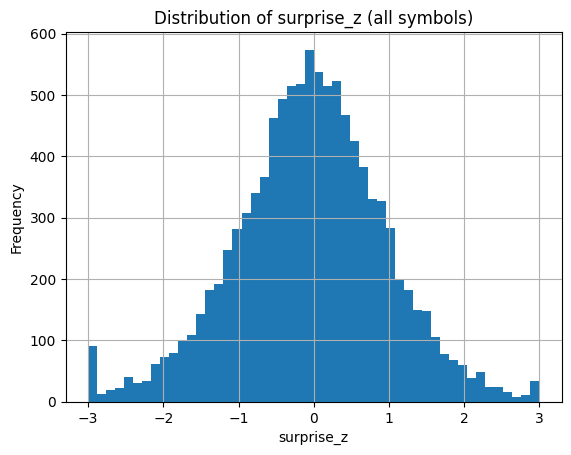

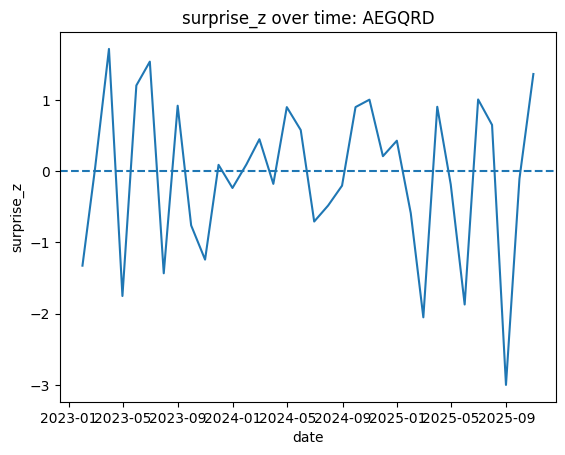

In [12]:
# 코드 셀
import matplotlib.pyplot as plt

# 전체 surprise 분포
plt.figure()
surprise_df['surprise_z'].dropna().hist(bins=50)
plt.title("Distribution of surprise_z (all symbols)")
plt.xlabel("surprise_z")
plt.ylabel("Frequency")
plt.show()

# 특정 심볼의 시계열 예시
sample = surprise_df[surprise_df['symbol'] == surprise_df['symbol'].iloc[0]]
plt.figure()
plt.plot(sample['date'], sample['surprise_z'])
plt.axhline(0, linestyle='--')
plt.title(f"surprise_z over time: {sample['symbol'].iloc[0]}")
plt.xlabel("date")
plt.ylabel("surprise_z")
plt.show()